## 1. Characteristics of Times Series

Here, we'll study some properties of returns series for asset AAPL, GLD, INTC, SPY

This notebook can be seen as an application of Chapter 1.

In [1]:
INDEX = ["AAPL", "GLD", "INTC", "SPY"]

from fts_tool.config import PRICES_DATA_SOURCE
from fts_tool.ingestion import YahooFinanceIngestor
import pandas as pd
import numpy as np

prices_df = {}

for ticker in INDEX:
    yf_ingestor = YahooFinanceIngestor(ticker=ticker, start_date="2018-01-01", end_date="2023-01-01", interval="1d")
    data = yf_ingestor.fetch_data()
    processed_data = yf_ingestor.process_data(data)

    yf_ingestor.store_data(processed_data)

    prices_df[ticker] = processed_data

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## Apple Stock Analysis

In [2]:
AAPL_prices = prices_df["AAPL"].Close.sort_index()

In [3]:
from fts_tool.analysis import FTSAnalyzer

ts_analyzer = FTSAnalyzer(AAPL_prices)

ts_analyzer.define_ts(ts_analyzer.returns)

C:\Users\chris\AppData\Roaming\Python\Python312\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.2)
  from scipy.stats import gaussian_kde


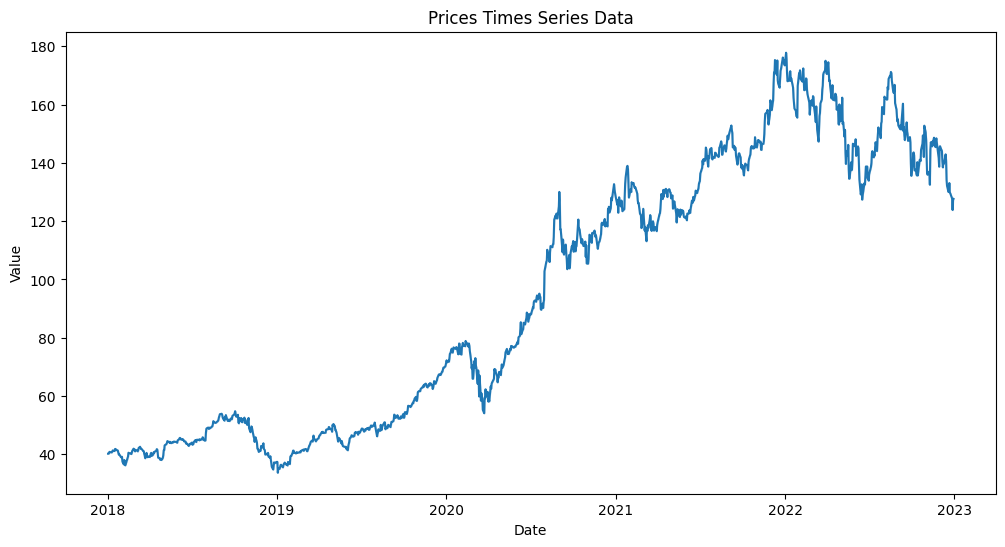

In [4]:
ts_analyzer.prices_plot()

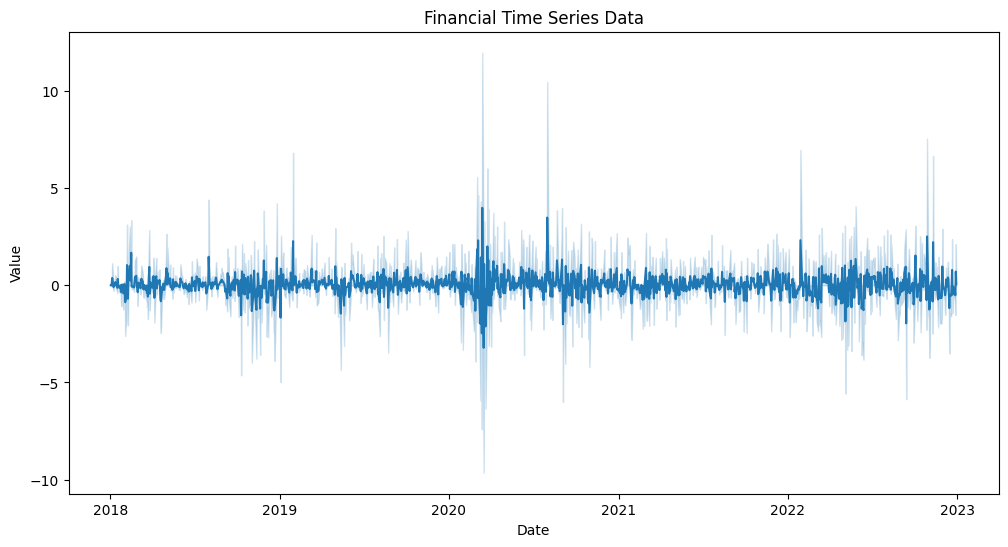

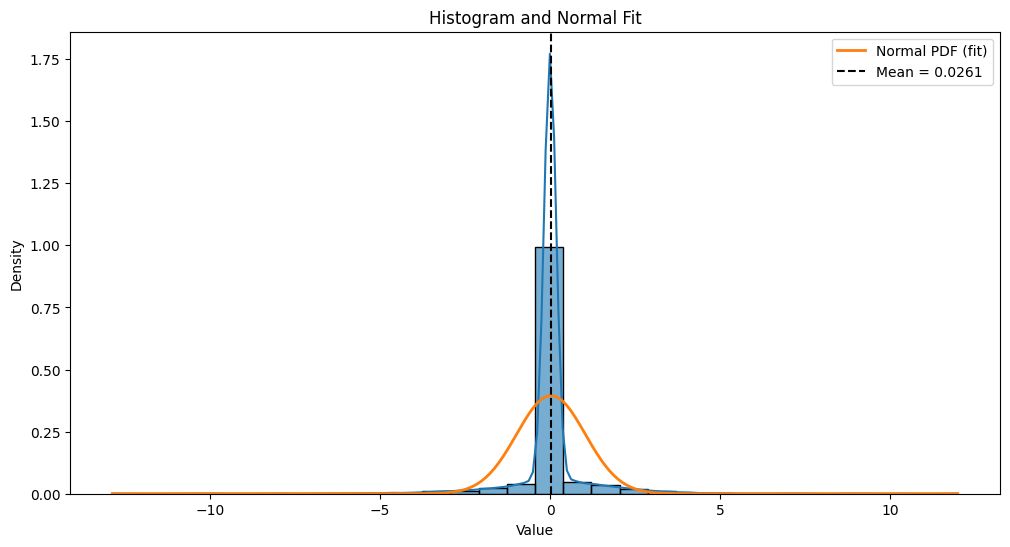

Summary of Financial Time Series Data:
Mean: 0.026067672212344413
Std: 1.0091809884559284
Min: -12.864705668820086
Max: 11.980823536150487
Excess Kurtosis: 26.58207053412913
Skewness: 0.20686634437755425
null_mean: {'hypothesis': 'H0: mean = 0', 'statistic': np.float64(1.9165133665667284), 'p_value': np.float64(0.05535151409630161), 'reject_null': False, 'note': 'Two-sided one-sample t-test.'}
null_skewness: {'hypothesis': 'H0: skewness = 0', 'statistic': np.float64(6.2677427930065726), 'p_value': np.float64(3.663191920623767e-10), 'reject_null': True, 'note': 'Approximate z-test for zero skewness.'}
null_kurtosis: {'hypothesis': 'H0: excess kurtosis = 0', 'statistic': np.float64(448.22768264761135), 'p_value': np.float64(0.0), 'reject_null': True, 'note': 'Approximate z-test for normal kurtosis.'}
jarque_bera: {'hypothesis': 'H0: data are normally distributed', 'statistic': np.float64(200765.0727246152), 'p_value': np.float64(0.0), 'reject_null': True, 'note': 'Jarque-Bera test for no

In [5]:
# Simple return analysis (in %)

ts_analyzer.define_ts(ts_analyzer.returns * 100)
ts_analyzer.plot_ts()
ts_analyzer.normal_adjustment()
ts_analyzer.print_summary()
Rtest = ts_analyzer.null_hypothesis()

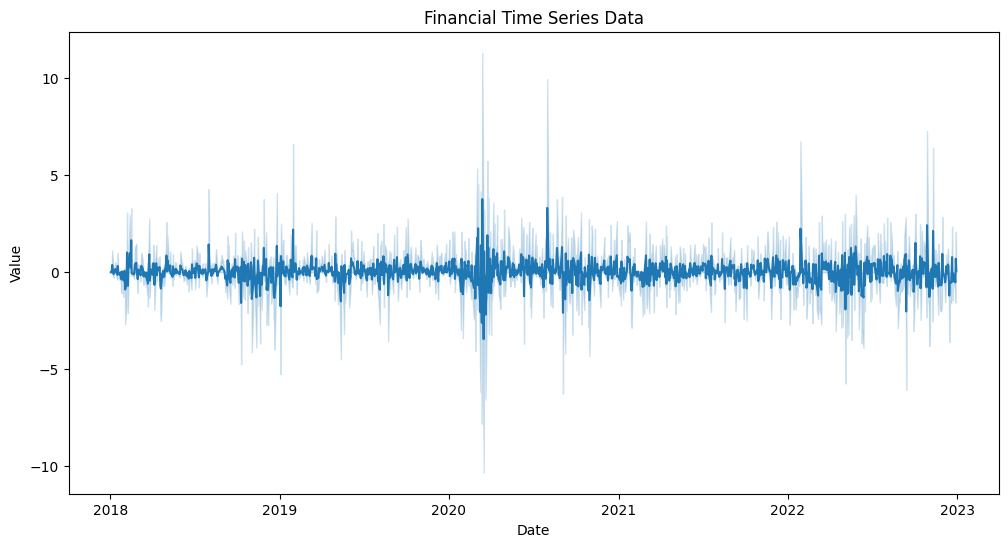

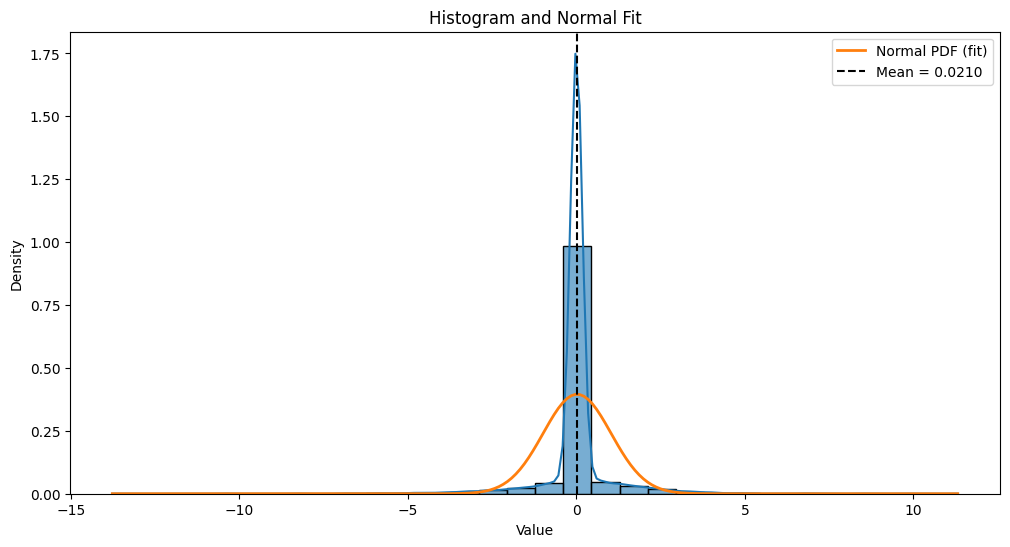

Summary of Financial Time Series Data:
Mean: 0.020974239918768848
Std: 1.0093918673561793
Min: -13.77081680057113
Max: 11.315745222022713
Excess Kurtosis: 27.14170329784939
Skewness: -0.27413708619531063
null_mean: {'hypothesis': 'H0: mean = 0', 'statistic': np.float64(1.5417185284806745), 'p_value': np.float64(0.12319949502787135), 'reject_null': False, 'note': 'Two-sided one-sample t-test.'}
null_skewness: {'hypothesis': 'H0: skewness = 0', 'statistic': np.float64(-8.305946293325194), 'p_value': np.float64(9.902702224045616e-17), 'reject_null': True, 'note': 'Approximate z-test for zero skewness.'}
null_kurtosis: {'hypothesis': 'H0: excess kurtosis = 0', 'statistic': np.float64(456.70724111957867), 'p_value': np.float64(0.0), 'reject_null': True, 'note': 'Approximate z-test for normal kurtosis.'}
jarque_bera: {'hypothesis': 'H0: data are normally distributed', 'statistic': np.float64(208461.24861923515), 'p_value': np.float64(0.0), 'reject_null': True, 'note': 'Jarque-Bera test for n

In [6]:
# Log return analysis (in %)

ts_analyzer.define_ts(ts_analyzer.log_returns * 100)
ts_analyzer.plot_ts()
ts_analyzer.normal_adjustment()
ts_analyzer.print_summary()
rtest = ts_analyzer.null_hypothesis()

### Interpretation
(French)

- Moyenne : La moyenne est bien centrée à 0 sur la période étudiée, cela est vérifié par le test statistiques H0 = moyenne nulle.
- Extremum : Les rendements extremes sont assez consequent. (Proposition d'etudier la distribution des extremes.)
- Distribution : Visuellement, on rejette l'hypothèse de rendement gaussian et le test de Jarque-Bera invalide la normalité. De plus, l'excess kurtosis denote que notre distribution à une queue plus lourde que celle d'une loi normale. (Tester d'ajuster d'autres loi comme celle mentionné dans le Chap 1.)
- Log vs Simple : Les log rendements et les rendements simples ont des series temporelle qui se comporte de manière similaires.